# PERGUNTA 1

# Progressão salarial por nível de experiência.

Importando as Blibliotecas **pandas, numpy e matplotlib.pylot**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Criando **FUNÇÃO** para carregar um arquivo **csv**

In [13]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

Puxando a **FUNÇÃO** através da **VARIÁVEL**, e retornando o **BANCO DE DADOS**

In [14]:
df = carregar_banco_csv(
    r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\4 - TECNICAS DE PROGRAMAÇÃO I (PY) - DE 12-05-2026 A 26-05-2026\PROJETO\salario_ciencia_dados.csv"
)
df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salario_moeda_corrente,moeda_corrente,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


# Qual é o salário médio em cada nível (EN, MI, SE, EX)?

Comandos para Retornar a **Média Salarial Geral** e **Média em cada Nível de Experiencia**

In [15]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por nível de experiência
salario_por_experiencia = df.groupby("nivel_experiencia")["salario_usd"].mean().round(2).sort_values()
salario_por_experiencia.head(10)

Média salarial geral de todos os funcionários: U$ 145560.56



nivel_experiencia
Entry-level         84448.92
Mid-level          119019.81
Senior-level       162071.06
Executive-level    189687.35
Name: salario_usd, dtype: float64

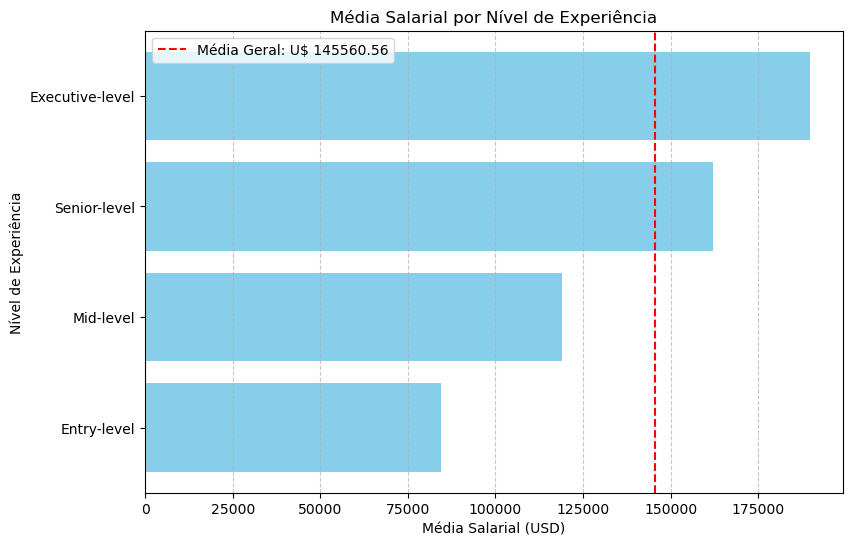

In [16]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
# Média salarial por nível de experiência
salario_por_experiencia = df.groupby("nivel_experiencia")["salario_usd"].mean().round(2).sort_values()
plt.figure(figsize=(9,6))
# Barras horizontais
plt.barh(salario_por_experiencia.index, salario_por_experiencia.values, color="skyblue")
# Linha da média geral
plt.axvline(x=media_geral, color="red", linestyle="--", label=f"Média Geral: U$ {media_geral}")
# Título e rótulos
plt.title("Média Salarial por Nível de Experiência")
plt.xlabel("Média Salarial (USD)")
plt.ylabel("Nível de Experiência")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# A progressão é parecida entre os cargos principais (Data Analyst, Data Scientist, Data Engineer)?

Comandos para comparação **CARGO x EXPERIÊNCIA.** Trazendo também o resultado da média por **CARGO** independente da experiência

In [18]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Filtrar apenas os cargos principais
cargos_principais = ["Data Analyst", "Data Scientist", "Data Engineer"]
df_filtrado = df[df["cargo"].isin(cargos_principais)]
# Média salarial por nível de experiência e cargo
progressao_por_cargo = df_filtrado.groupby(["cargo", "nivel_experiencia"])["salario_usd"].mean().unstack().round(2)
# Adicionar coluna com a média salarial do cargo
progressao_por_cargo["media_cargo"] = progressao_por_cargo.mean(axis=1).round(2)
progressao_por_cargo.head()

Média salarial geral de todos os funcionários: U$ 145560.56



nivel_experiencia,Entry-level,Executive-level,Mid-level,Senior-level,media_cargo
cargo,,,,,
Data Analyst,78290.84,114107.14,94854.81,122400.54,102413.33
Data Engineer,79441.09,195357.38,117253.14,156129.57,137045.29
Data Scientist,83387.10,189050.52,115501.05,169793.45,139433.03


Comando para Visualização em **GRÁFICO** com o resultado das variáveis calculadas

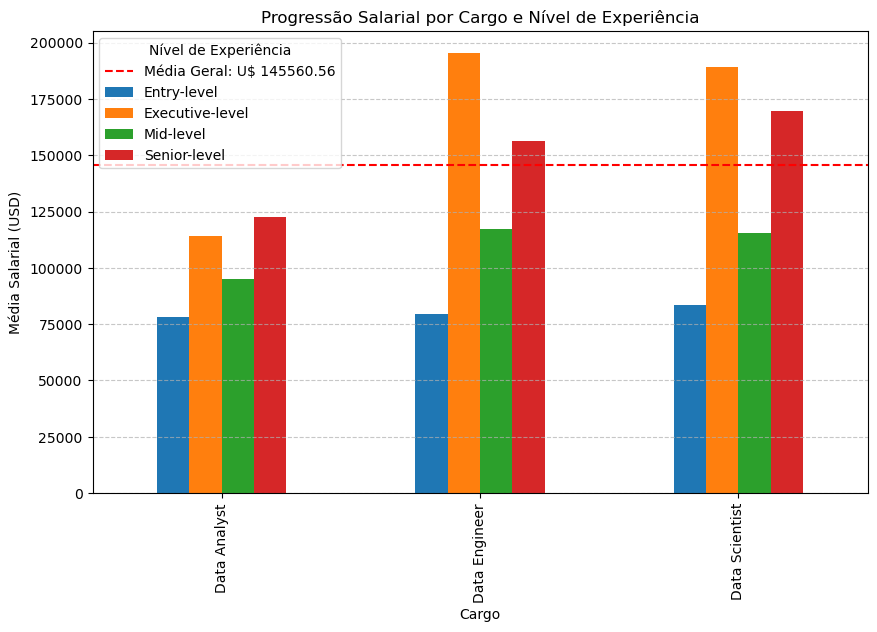

In [19]:
# Remover a coluna de média para o gráfico principal
df_plot = progressao_por_cargo.drop(columns=["media_cargo"])
# Criar gráfico de barras agrupadas
df_plot.plot(kind="bar", figsize=(10,6))
# Linha da média geral
media_geral = round(df["salario_usd"].mean(), 2)
plt.axhline(y=media_geral, color="red", linestyle="--", label=f"Média Geral: U$ {media_geral}")
# Título e rótulos
plt.title("Progressão Salarial por Cargo e Nível de Experiência")
plt.xlabel("Cargo")
plt.ylabel("Média Salarial (USD)")
plt.legend(title="Nível de Experiência")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()